In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
#from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


2024-09-02 19:08:13.159362: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-02 19:08:14.407364: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-02 19:08:17.199989: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-02 19:08:21.859912: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
def index_containing_substring(the_list, substring):
    try:
        return [s for i, s in enumerate(the_list) if substring in s][0]
    except IndexError:
        return False

In [5]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


!unzip -q /workspaces/work/Cropped_data-20240527T214451Z-001.zip

import os.path


data_path = "/workspaces/work/Dataset/Cropped_data"
devices = os.listdir(data_path)
target_dir ="/workspaces/work/Dataset/Cropped_data/Device_1/Cihaz_1"
#"/workspaces/work/Cropped_data/Device_1/Cihaz_1"
crop_len = float('inf')

def extract_IQ_samples_from_txt_file(path_to_txt, crop_len):

    I_samples = []
    Q_samples = []

    files = os.listdir(target_dir)
    Real = [file for file in files if 'I' in file]
    Imaginary = [file for file in files if 'Q' in file]

    for file in Real:
        file_number = file.split('.')[0][1:]
        I_path_temp = index_containing_substring(Real, file_number)
        Q_temp_path = index_containing_substring(Imaginary, file_number)
        if Q_temp_path != False:
            I_path_temp = os.path.join(target_dir, I_path_temp)
            Q_temp_path = os.path.join(target_dir, Q_temp_path)
        
            I_sample = np.loadtxt(I_path_temp)
            Q_sample = np.loadtxt(Q_temp_path)

            I_len = len(I_sample)
            Q_len = len(Q_sample)

            if I_len < crop_len:
                crop_len = I_len
            if Q_len < crop_len:
                crop_len = Q_len
                
            I_samples.append(I_sample)
            Q_samples.append(Q_sample)

    return I_samples, Q_samples, crop_len


unzip:  cannot find or open /workspaces/work/Cropped_data-20240527T214451Z-001.zip, /workspaces/work/Cropped_data-20240527T214451Z-001.zip.zip or /workspaces/work/Cropped_data-20240527T214451Z-001.zip.ZIP.


In [6]:
device1_path = "/workspaces/work/Dataset/Cropped_data/Device_1/Cihaz_1"
device2_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_2"
device3_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_3"
device4_path = "/workspaces/work/Dataset/Cropped_data/Device_2/Cihaz_4"

I_samples_1, Q_samples_1, crop_len1 = extract_IQ_samples_from_txt_file(device1_path, crop_len)
I_samples_2, Q_samples_2, crop_len2 = extract_IQ_samples_from_txt_file(device2_path, crop_len1)
I_samples_3, Q_samples_3, crop_len3 = extract_IQ_samples_from_txt_file(device3_path, crop_len2)
I_samples_4, Q_samples_4, crop_len4 = extract_IQ_samples_from_txt_file(device4_path, crop_len3)

In [7]:
assert(len(I_samples_1) == len(Q_samples_1)), "lengths not equal for device 1"
assert(len(I_samples_2) == len(Q_samples_2)), "lengths not equal for device 2"
assert(len(I_samples_3) == len(Q_samples_3)), "lengths not equal for device 3"
assert(len(I_samples_4) == len(Q_samples_4)), "lengths not equal for device 4"

In [9]:
crop_len = 3000
#crop_len = crop_len4
samples_from_each_device = 843
I_samples_1, Q_samples_1 = [I_samples_1[i][:crop_len] for i in range(len(I_samples_1))], [Q_samples_1[i][:crop_len] for i in range(len(Q_samples_1))]
I_samples_2, Q_samples_2 = [I_samples_2[i][:crop_len] for i in range(len(I_samples_2))], [Q_samples_2[i][:crop_len] for i in range(len(Q_samples_2))]
I_samples_3, Q_samples_3 = [I_samples_3[i][:crop_len] for i in range(len(I_samples_3))], [Q_samples_3[i][:crop_len] for i in range(len(Q_samples_3))]
I_samples_4, Q_samples_4 = [I_samples_4[i][:crop_len] for i in range(len(I_samples_4))], [Q_samples_4[i][:crop_len] for i in range(len(Q_samples_4))]

In [10]:
samples_from_each_device = 843

In [11]:
assert(len(I_samples_1) == len(Q_samples_1) == len(I_samples_2) == len(Q_samples_2) == len(I_samples_3) == len(Q_samples_3) == len(I_samples_4) == len(Q_samples_4)), "lengths not equal for all device 1"
I_samples_1, Q_samples_1 = np.array(I_samples_1), np.array(Q_samples_1)
I_samples_2, Q_samples_2 = np.array(I_samples_2), np.array(Q_samples_2)
I_samples_3, Q_samples_3 = np.array(I_samples_3), np.array(Q_samples_3)
I_samples_4, Q_samples_4 = np.array(I_samples_4), np.array(Q_samples_4)


In [14]:
I_samples_1.shape

(843, 3000)

In [18]:
samples_from_each_device = I_samples_1.shape[0]
real_part = np.vstack((I_samples_1, I_samples_2, I_samples_3, I_samples_4))
imaginary_part = np.vstack((Q_samples_1, Q_samples_2, Q_samples_3, Q_samples_4))


In [21]:
labels1 = np.array([0 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels2 = np.array([1 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels3 = np.array([2 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels4 = np.array([3 for i in range(samples_from_each_device)]).reshape(samples_from_each_device, 1)
labels = np.vstack((labels1, labels2, labels3, labels4))
print(labels.shape, real_part.shape)

(3372, 1) (3372, 3000)


In [22]:
print(imaginary_part[0])

[-3.100e-05 -4.300e-05  2.100e-05 ...  4.109e-03 -9.400e-05 -4.552e-03]


In [24]:
data = real_part + 1j * imaginary_part

In [26]:
print(data.shape)

(3372, 3000)


In [37]:
print(data)

[[ 6.500e-05-3.100e-05j  1.040e-04-4.300e-05j  9.300e-05+2.100e-05j ...
  -7.871e-03+4.109e-03j -9.427e-03-9.400e-05j -8.994e-03-4.552e-03j]
 [-3.815e-03-1.302e-03j -3.930e-03+1.064e-03j -3.005e-03+3.239e-03j ...
  -7.282e-03+2.510e-04j -7.188e-03-1.779e-03j -6.580e-03-3.797e-03j]
 [-3.539e-03+3.817e-03j -1.515e-03+1.833e-03j  1.347e-03-1.168e-03j ...
  -8.930e-04+7.132e-03j -6.520e-04+4.189e-03j -5.760e-04+8.470e-04j]
 ...
 [-6.100e-05+1.310e-04j -3.500e-05+1.420e-04j  9.700e-05-2.100e-05j ...
  -8.127e-03+4.980e-04j -7.771e-03-1.350e-03j -7.125e-03-2.993e-03j]
 [ 3.886e-03+5.799e-03j  6.811e-03+3.051e-03j  7.817e-03-1.433e-03j ...
   4.342e-03-8.626e-03j  6.860e-03-5.694e-03j  8.125e-03-1.832e-03j]
 [ 2.284e-03+1.303e-03j  2.819e-03+1.150e-04j  2.782e-03-1.351e-03j ...
   2.929e-03-6.713e-03j  4.356e-03-5.887e-03j  5.942e-03-4.501e-03j]]


In [28]:
snr_range = np.arange(20,80)

data = awgn(data, snr_range)

In [30]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)



In [32]:
data=augmented_sample

/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


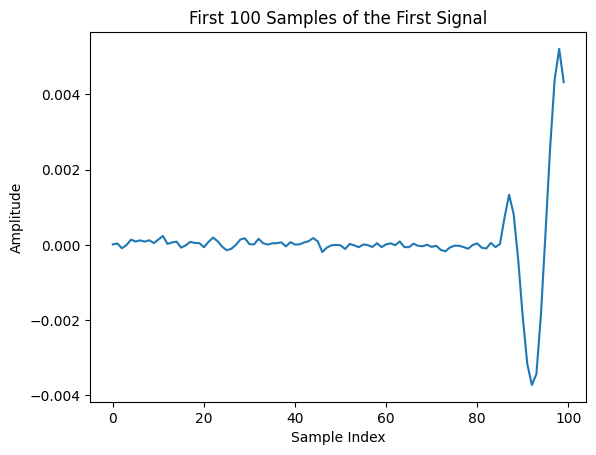

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

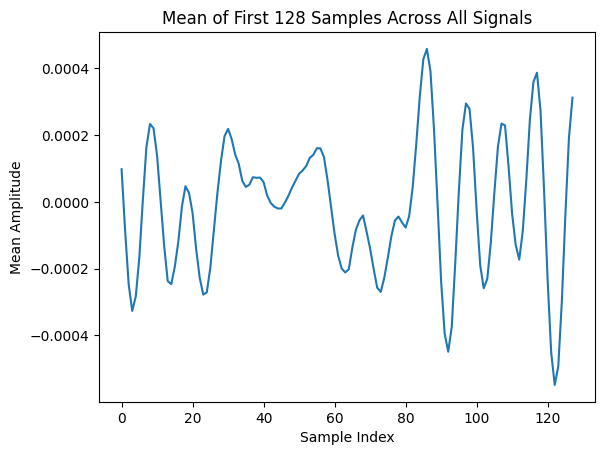

Suspected Preamble: [ 9.79137030e-05-9.90558113e-06j -8.62518201e-05-5.74637839e-05j
 -2.47102585e-04-4.24478233e-05j -3.26908633e-04+2.87202804e-05j
 -2.83378899e-04+1.11849528e-04j -1.66779632e-04+1.74746121e-04j
  6.56715504e-06+1.77642269e-04j  1.64905884e-04+1.17081276e-04j
  2.33342161e-04-1.43162339e-05j  2.20809333e-04-1.52472962e-04j
  1.38261983e-04-2.62176249e-04j  4.10232127e-06-3.04924054e-04j
 -1.32131850e-04-2.66021723e-04j -2.37518269e-04-1.45794370e-04j
 -2.46680216e-04-7.55499447e-06j -1.93564428e-04+1.31853428e-04j
 -1.17586211e-04+2.29963259e-04j -1.30906030e-05+2.38788807e-04j
  4.72237093e-05+1.67149330e-04j  2.63779449e-05+2.17875099e-05j
 -3.34292077e-05-1.22956220e-04j -1.40884299e-04-2.24560846e-04j
 -2.27132393e-04-2.71854679e-04j -2.77963316e-04-2.33324705e-04j
 -2.71412509e-04-1.11588552e-04j -1.96659863e-04+4.62228555e-05j
 -8.39111003e-05+1.96682867e-04j  2.76468376e-05+2.88481080e-04j
  1.22396578e-04+3.20692199e-04j  1.97026312e-04+2.61186440e-04j
  2.1

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 128  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 128 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


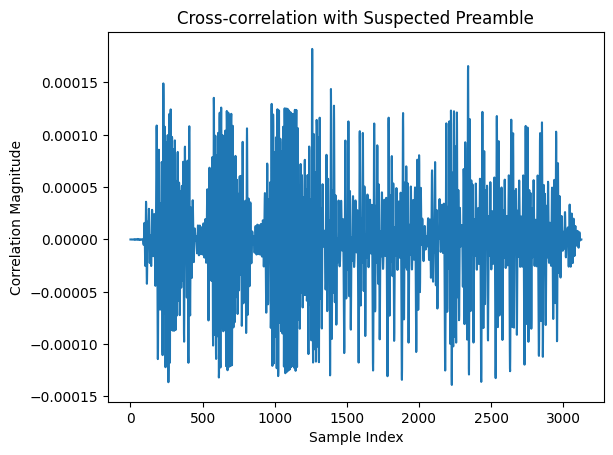

Peak correlation index: 1260
Peak correlation value: (0.00018205460636308+4.36867870680249e-05j)
Synchronized signal start index: 1133


In [37]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [40]:
import numpy as np

# Given values
peak_index =1260
preamble_length = 128  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [ 0.00150377-8.60888692e-03j -0.0037205 -7.63066057e-03j
 -0.00773105-3.85813032e-03j -0.00876806+1.67422937e-03j
 -0.00614506+6.57261885e-03j -0.0015863 +9.09100751e-03j
  0.00373319+8.41815927e-03j  0.00807165+4.54251589e-03j
  0.00910344-8.54257210e-04j  0.00676251-5.72681397e-03j
  0.00224484-8.49405633e-03j -0.00312481-7.98608303e-03j
 -0.00740736-4.48343178e-03j -0.00884906+4.98513609e-04j
 -0.00726114+5.24150395e-03j -0.00351346+8.43267731e-03j
  0.00167488+9.11771399e-03j  0.00647381+6.63607288e-03j
  0.00889219+2.05211672e-03j  0.00861879-2.53741468e-03j
  0.00616816-6.39325834e-03j  0.00177576-8.51181171e-03j
 -0.00284958-7.99554801e-03j -0.00661874-5.25731114e-03j
 -0.00867896-1.20097297e-03j -0.00832542+3.05664666e-03j
 -0.00642699+6.31347659e-03j -0.0033283 +8.47782211e-03j
  0.00032161+9.39970405e-03j  0.00368028+8.44026658e-03j
  0.0064256 +6.60198486e-03j  0.00826383+4.43024117e-03j
  0.00904673+1.60660667e-03j  0.00894884-1.06013777e-03j
  0.0082335

In [45]:
preamble=suspected_preamble
data_input=data

In [46]:
preamble

array([ 0.00150377-8.60888692e-03j, -0.0037205 -7.63066057e-03j,
       -0.00773105-3.85813032e-03j, -0.00876806+1.67422937e-03j,
       -0.00614506+6.57261885e-03j, -0.0015863 +9.09100751e-03j,
        0.00373319+8.41815927e-03j,  0.00807165+4.54251589e-03j,
        0.00910344-8.54257210e-04j,  0.00676251-5.72681397e-03j,
        0.00224484-8.49405633e-03j, -0.00312481-7.98608303e-03j,
       -0.00740736-4.48343178e-03j, -0.00884906+4.98513609e-04j,
       -0.00726114+5.24150395e-03j, -0.00351346+8.43267731e-03j,
        0.00167488+9.11771399e-03j,  0.00647381+6.63607288e-03j,
        0.00889219+2.05211672e-03j,  0.00861879-2.53741468e-03j,
        0.00616816-6.39325834e-03j,  0.00177576-8.51181171e-03j,
       -0.00284958-7.99554801e-03j, -0.00661874-5.25731114e-03j,
       -0.00867896-1.20097297e-03j, -0.00832542+3.05664666e-03j,
       -0.00642699+6.31347659e-03j, -0.0033283 +8.47782211e-03j,
        0.00032161+9.39970405e-03j,  0.00368028+8.44026658e-03j,
        0.0064256 +6.6019

In [55]:
import numpy as np

def generate_pilot_sequence(preamble_array):
    # Extract the real and imaginary parts of the preamble array
    real_part = np.real(preamble_array)
    imag_part = np.imag(preamble_array)
    
    # Combine the real and imaginary parts to form the pilot sequence
    pilot_sequence = np.column_stack((real_part, imag_part)).flatten()
    
    return pilot_sequence

# Example usage
preamble = np.array([ 1.15808360e-03-8.65162952e-03j, -4.17126391e-03-7.59005302e-03j,
       -7.96230944e-03-3.47191039e-03j, -8.60041533e-03+2.22043071e-03j,
       -5.90682488e-03+6.93170763e-03j, -1.02135699e-03+9.18832198e-03j,
        4.22393784e-03+8.26022565e-03j,  8.02782814e-03+4.38100461e-03j,
        9.02726443e-03-9.55948962e-04j,  6.43913446e-03-6.04007755e-03j,
        1.47394675e-03-8.62400917e-03j, -3.70041545e-03-7.64923408e-03j,
       -7.72258388e-03-3.84856067e-03j, -8.77886531e-03+1.62878638e-03j,
       -6.18328302e-03+6.57216554e-03j, -1.58127595e-03+9.10281214e-03j,
        3.74231923e-03+8.40606992e-03j,  8.07593424e-03+4.51961710e-03j,
        9.10784022e-03-8.25883516e-04j,  6.75906888e-03-5.71449570e-03j,
        2.25106437e-03-8.52407638e-03j, -3.11186245e-03-8.00921889e-03j,
       -7.39028232e-03-4.51378388e-03j, -8.84972506e-03+4.74573414e-04j,
       -7.25790696e-03+5.22628905e-03j, -3.47309372e-03+8.41806859e-03j,
        1.67575883e-03+9.10561811e-03j,  6.48486469e-03+6.62205514e-03j,
        8.87161889e-03+2.09795692e-03j,  8.65022563e-03-2.55391338e-03j,
        6.15557730e-03-6.41156500e-03j,  1.81165751e-03-8.49407593e-03j,
       -2.87503297e-03-7.96696459e-03j, -6.67917856e-03-5.22557278e-03j,
       -8.66629766e-03-1.19816115e-03j, -8.36319124e-03+3.05082879e-03j,
       -6.44532068e-03+6.30556835e-03j, -3.35101451e-03+8.48121143e-03j,
        3.22020298e-04+9.41626067e-03j,  3.64905341e-03+8.42903346e-03j,
        6.41399730e-03+6.57334182e-03j,  8.27163629e-03+4.46072193e-03j,
        9.03734434e-03+1.61181509e-03j,  8.97936356e-03-1.03769876e-03j,
        8.26850812e-03-3.28579833e-03j,  7.32015154e-03-5.30722945e-03j,
        6.14636555e-03-6.52071374e-03j,  4.85985060e-03-7.28002358e-03j,
        4.08172098e-03-7.73902247e-03j,  3.50907117e-03-7.88406856e-03j,
        2.99276591e-03-8.19324912e-03j,  2.99001464e-03-8.20735240e-03j,
        3.20605509e-03-7.92190176e-03j,  3.54469129e-03-7.84321579e-03j,
        4.15287221e-03-7.60765043e-03j,  4.97976010e-03-7.02126255e-03j,
        5.94413071e-03-6.20419001e-03j,  6.87642349e-03-5.08583569e-03j,
        7.89095678e-03-3.50069554e-03j,  8.58558888e-03-1.55660052e-03j,
        8.60063040e-03+4.59920542e-04j,  8.33797502e-03+2.68533782e-03j,
        7.38572548e-03+5.11415218e-03j,  5.43222617e-03+7.24331359e-03j,
        3.02997302e-03+8.63354076e-03j,  9.20217588e-05+9.18301084e-03j,
       -3.23258683e-03+8.75864821e-03j, -6.25799346e-03+6.83543568e-03j,
       -8.43043031e-03+3.61081953e-03j, -9.17449131e-03+3.50579206e-05j,
       -8.39032685e-03-3.52313655e-03j, -6.02023084e-03-6.56664159e-03j,
       -2.22722436e-03-8.34276903e-03j,  1.70327202e-03-8.50722942e-03j,
        4.98826004e-03-6.96169156e-03j,  7.58458221e-03-4.07904085e-03j,
        8.84897144e-03-3.55227017e-04j,  8.15498875e-03+3.53794681e-03j,
        5.94385269e-03+6.65599683e-03j,  2.81998958e-03+8.70252029e-03j,
       -9.69590429e-04+9.24448889e-03j, -4.60582450e-03+7.97156220e-03j,
       -7.24124067e-03+5.76617533e-03j, -8.80624317e-03+2.84175332e-03j,
       -9.21886864e-03-7.37468929e-04j, -8.20388333e-03-3.87491411e-03j,
       -6.09621069e-03-6.32445446e-03j, -3.61145415e-03-7.99930916e-03j,
       -1.28014073e-03-8.50879670e-03j,  8.71757425e-04-8.43247048e-03j,
        2.85376990e-03-8.05029879e-03j,  4.50576737e-03-7.11466751e-03j,
        5.79180850e-03-6.03818643e-03j,  6.72086759e-03-5.06207521e-03j,
        7.48554581e-03-3.97994451e-03j,  8.07392941e-03-2.98638885e-03j,
        8.28675932e-03-2.38952353e-03j,  8.31474493e-03-2.01992799e-03j,
        8.23674829e-03-2.09932125e-03j,  7.98746495e-03-2.80871636e-03j,
        7.61979656e-03-3.50249774e-03j,  7.04932175e-03-4.16348781e-03j,
        6.34600920e-03-5.17247846e-03j,  5.22796270e-03-6.22761651e-03j,
        3.70804913e-03-7.25741006e-03j,  2.10474377e-03-8.04939621e-03j,
       -1.26941514e-04-8.14818851e-03j, -2.98586873e-03-7.68019983e-03j,
       -5.61865443e-03-6.57418510e-03j, -7.76765397e-03-4.45417167e-03j,
       -9.13373924e-03-1.35241664e-03j, -9.37775355e-03+2.25624357e-03j,
       -8.21844548e-03+5.58066021e-03j, -5.49106388e-03+8.11548797e-03j,
       -1.75019695e-03+9.61851230e-03j,  2.34373304e-03+9.34172274e-03j,
        6.09150560e-03+6.87965769e-03j,  8.30745187e-03+2.71420379e-03j,
        8.22066982e-03-2.14498911e-03j,  5.64649910e-03-6.18890826e-03j,
        1.18841827e-03-8.15101985e-03j, -3.72184966e-03-7.61831709e-03j,
       -7.59568166e-03-4.63392500e-03j, -9.30048458e-03+1.57395762e-04j,
       -8.09152049e-03+5.34800714e-03j, -4.06416553e-03+8.90195211e-03j,
        1.28178584e-03+9.33432098e-03j,  5.87203263e-03+6.92208845e-03j])  # Replace with your actual preamble array
pilot_sequence = generate_pilot_sequence(preamble)
print(pilot_sequence)


[ 1.15808360e-03 -8.65162952e-03 -4.17126391e-03 -7.59005302e-03
 -7.96230944e-03 -3.47191039e-03 -8.60041533e-03  2.22043071e-03
 -5.90682488e-03  6.93170763e-03 -1.02135699e-03  9.18832198e-03
  4.22393784e-03  8.26022565e-03  8.02782814e-03  4.38100461e-03
  9.02726443e-03 -9.55948962e-04  6.43913446e-03 -6.04007755e-03
  1.47394675e-03 -8.62400917e-03 -3.70041545e-03 -7.64923408e-03
 -7.72258388e-03 -3.84856067e-03 -8.77886531e-03  1.62878638e-03
 -6.18328302e-03  6.57216554e-03 -1.58127595e-03  9.10281214e-03
  3.74231923e-03  8.40606992e-03  8.07593424e-03  4.51961710e-03
  9.10784022e-03 -8.25883516e-04  6.75906888e-03 -5.71449570e-03
  2.25106437e-03 -8.52407638e-03 -3.11186245e-03 -8.00921889e-03
 -7.39028232e-03 -4.51378388e-03 -8.84972506e-03  4.74573414e-04
 -7.25790696e-03  5.22628905e-03 -3.47309372e-03  8.41806859e-03
  1.67575883e-03  9.10561811e-03  6.48486469e-03  6.62205514e-03
  8.87161889e-03  2.09795692e-03  8.65022563e-03 -2.55391338e-03
  6.15557730e-03 -6.41156

In [56]:
pilot_sequence

array([ 1.15808360e-03, -8.65162952e-03, -4.17126391e-03, -7.59005302e-03,
       -7.96230944e-03, -3.47191039e-03, -8.60041533e-03,  2.22043071e-03,
       -5.90682488e-03,  6.93170763e-03, -1.02135699e-03,  9.18832198e-03,
        4.22393784e-03,  8.26022565e-03,  8.02782814e-03,  4.38100461e-03,
        9.02726443e-03, -9.55948962e-04,  6.43913446e-03, -6.04007755e-03,
        1.47394675e-03, -8.62400917e-03, -3.70041545e-03, -7.64923408e-03,
       -7.72258388e-03, -3.84856067e-03, -8.77886531e-03,  1.62878638e-03,
       -6.18328302e-03,  6.57216554e-03, -1.58127595e-03,  9.10281214e-03,
        3.74231923e-03,  8.40606992e-03,  8.07593424e-03,  4.51961710e-03,
        9.10784022e-03, -8.25883516e-04,  6.75906888e-03, -5.71449570e-03,
        2.25106437e-03, -8.52407638e-03, -3.11186245e-03, -8.00921889e-03,
       -7.39028232e-03, -4.51378388e-03, -8.84972506e-03,  4.74573414e-04,
       -7.25790696e-03,  5.22628905e-03, -3.47309372e-03,  8.41806859e-03,
        1.67575883e-03,  

In [57]:
import numpy as np

# Your data array
#data = np.array([ 6.44094009e-03, -6.04295221e-03,  1.47215145e-03, -8.62821254e-03,
 #      -3.70091598e-03, -7.65039961e-03, -7.71739803e-03, -3.85034659e-03,
  #     -8.78449404e-03,  1.62612579e-03, -6.18889344e-03,  6.57447068e-03,
   #    -1.58355382e-03,  9.10230441e-03,  3.74007803e-03,  8.40155417e-03])
data=pilot_sequence
# Min-Max Normalization
data_min = np.min(data)
data_max = np.max(data)
data_min_max_normalized = (data - data_min) / (data_max - data_min)

# Z-score Normalization
#data_mean = np.mean(data)
#data_std = np.std(data)
#data_z_score_normalized = (data - data_mean) / data_std

print("Min-Max Normalized Data:")
print(data_min_max_normalized)

#print("Z-score Normalized Data:")
#print(data_z_score_normalized)


Min-Max Normalized Data:
[0.55462675 0.03822457 0.27407964 0.094108   0.0745117  0.31089495
 0.04092058 0.61055074 0.18271637 0.85856143 0.4398968  0.97735395
 0.71601922 0.92849718 0.91626332 0.72428751 0.96887557 0.44334
 0.83263143 0.17570169 0.57125439 0.03967856 0.29886601 0.09099259
 0.08713132 0.29106736 0.03152663 0.57940545 0.16816308 0.83963444
 0.41042159 0.97285255 0.69066589 0.9361747  0.91879572 0.73158434
 0.97311724 0.4501869  0.84947339 0.19284094 0.61216336 0.04493921
 0.32984857 0.0720423  0.10462431 0.25604873 0.02779644 0.51864546
 0.1115928  0.76878491 0.31083266 0.93680633 0.58187817 0.97300026
 0.83503876 0.84226073 0.96068209 0.60410349 0.94902753 0.35922008
 0.81770444 0.15614587 0.58903214 0.04651849 0.34231573 0.07426665
 0.14205818 0.21857879 0.03745241 0.43058949 0.05340851 0.6542645
 0.15436891 0.82560025 0.31725914 0.94013029 0.51061477 0.98935308
 0.68575619 0.93738354 0.83130816 0.83969636 0.92909785 0.72848399
 0.9694062  0.57851205 0.96635398 0.43903

In [59]:
pilot=data_min_max_normalized

In [61]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
#pilot = np.random.randn(len(preamble))
#pilot=np.array([])



# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


/tmp/ipykernel_7727/2745898976.py:29: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]


Most Common Synchronization Offset: 1078


In [69]:
data=compensated_data

In [72]:

def normalization(data):
    normalized_results = []
    count = 0

    for signal in data:
            # Min-max normalizasyonu
        min_val = np.min(signal)
        max_val = np.max(signal)
        normalized_result = (signal - min_val) / (max_val - min_val)

        count = count +1
        print(count)
        normalized_results.append(normalized_result)

    return np.array(normalized_results)
  
    


In [74]:
normalized_data=normalization(data)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [77]:

data=normalized_data




In [92]:
def normalize_data(data):
    rms = np.sqrt(np.mean(np.abs(data)**2))
    return data / rms
normalised_data = normalize_data(data)

In [95]:
data=normalised_data

In [96]:
data

array([[1.4694257 +0.j        , 1.67889214+0.j        ,
        1.59622537+0.j        , ..., 0.26645456+0.j        ,
        0.13749147+0.j        , 0.17311573+0.j        ],
       [0.1062417 +0.j        , 0.09738653+0.j        ,
        0.29372839+0.j        , ..., 0.1769222 +0.j        ,
        0.20387958+0.j        , 0.28285176+0.j        ],
       [1.50229825+0.j        , 1.50673365+0.j        ,
        1.29314739+0.j        , ..., 0.73570887+0.j        ,
        0.75195047+0.j        , 0.77017284+0.j        ],
       ...,
       [1.2111093 +0.12440728j, 1.47371334+0.09302464j,
        1.4904065 +0.08347778j, ..., 0.81166607-0.46202443j,
        0.80687251-0.43058222j, 0.80539053-0.37437283j],
       [1.17400185+0.j        , 1.18270257+0.j        ,
        1.22719606+0.j        , ..., 1.30252585+0.j        ,
        1.51611859+0.j        , 1.6227321 +0.j        ],
       [1.61201506-0.08713284j, 1.50774776-0.0864248j ,
        1.324017  -0.07434047j, ..., 0.85794475+0.22967075j,
 

In [97]:
labels

array([[0],
       [0],
       [0],
       ...,
       [3],
       [3],
       [3]])

In [101]:
import numpy as np

# Example complex data
complex_data = data
    # Add more rows as needed

real_part = complex_data.real
imaginary_part = complex_data.imag

# Normalize real and imaginary parts
real_part = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)
# Combine along a new axis
combined_data = np.stack((real_part, imaginary_part), axis=-1)

print(combined_data.shape)  # Should be (rows, cols, 2)
# Assuming combined_data is your full dataset
# For example purposes, let's create dummy labels
labels = labels # Replace with your actual labels



# Reshape if needed, for instance, if each data point is an "image"
#combined_data = combined_data.reshape((combined_data.shape[0], combined_data.shape[1], 2, 1))  # Example reshaping




(3372, 1922, 2)


In [102]:
import numpy as np
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming complex_data, real_part, and imaginary_part are already defined and normalized

# Function to compute spectrogram
def compute_spectrogram(data, fs=1.0, nperseg=256):
    f, t, Sxx = spectrogram(data, fs=fs, nperseg=nperseg)
    return Sxx

# Compute spectrograms for real and imaginary parts
real_spectrograms = np.array([compute_spectrogram(row) for row in real_part])
imaginary_spectrograms = np.array([compute_spectrogram(row) for row in imaginary_part])

# Combine real and imaginary spectrograms along the channel axis
combined_spectrograms = np.stack((real_spectrograms, imaginary_spectrograms), axis=-1)

print(combined_spectrograms.shape)  # Should be (num_samples, freq_bins, time_bins, 2)

# Assuming labels is already defined
X_train, X_test, y_train, y_test = train_test_split(combined_spectrograms, labels, test_size=0.2, random_state=42)

input_shape = (combined_spectrograms.shape[1], combined_spectrograms.shape[2], combined_spectrograms.shape[3])

model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='linear', input_shape=input_shape),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
   # MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(64, kernel_size=(3, 3), activation='linear'),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    #MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, kernel_size=(3, 3), activation='linear'),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    #MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='linear'),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')  # Assuming 4 classes
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, batch_size=64, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')


(3372, 129, 8, 2)
Epoch 1/10


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.2369 - loss: 2.7283 - val_accuracy: 0.2415 - val_loss: 2.6469 - learning_rate: 0.0010
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.2521 - loss: 1.9227 - val_accuracy: 0.2178 - val_loss: 1.6848 - learning_rate: 0.0010
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.2446 - loss: 1.8184 - val_accuracy: 0.1926 - val_loss: 1.5948 - learning_rate: 0.0010
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.2459 - loss: 1.7428 - val_accuracy: 0.2474 - val_loss: 1.4895 - learning_rate: 0.0010
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 161ms/step - accuracy: 0.2807 - loss: 1.6276 - val_accuracy: 0.2015 - val_loss: 1.4891 - learning_rate: 0.0010
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.2559 - loss: 1.6238 - val_accuracy: 0.2178 - val_loss: 1.4516 - learning_rate: 0.0010
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.2524 - loss: 1.5752 - val_acc

In [97]:
import numpy as np
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming complex_data, real_part, and imaginary_part are already defined and normalized

# Function to compute spectrogram
def compute_spectrogram(data, fs=1.0, nperseg=256):
    f, t, Sxx = spectrogram(data, fs=fs, nperseg=nperseg)
    return Sxx

# Compute spectrograms for real and imaginary parts
real_spectrograms = np.array([compute_spectrogram(row) for row in real_part])
imaginary_spectrograms = np.array([compute_spectrogram(row) for row in imaginary_part])

# Combine real and imaginary spectrograms along the channel axis
combined_spectrograms = np.stack((real_spectrograms, imaginary_spectrograms), axis=-1)

print(combined_spectrograms.shape)  # Should be (num_samples, freq_bins, time_bins, 2)

# Assuming labels is already defined
X_train, X_test, y_train, y_test = train_test_split(combined_spectrograms, labels, test_size=0.2, random_state=42)

input_shape = (combined_spectrograms.shape[1], combined_spectrograms.shape[2], combined_spectrograms.shape[3])

model = Sequential([
    Conv2D(32, kernel_size=(1, 1), activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(1, 1), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(1, 1), activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # Assuming 4 classes
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=500, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')


(3372, 129, 7, 2)
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2510 - loss: 2.3477 - val_accuracy: 0.2444 - val_loss: 1.3849 - learning_rate: 0.0010
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2638 - loss: 1.3862 - val_accuracy: 0.2400 - val_loss: 1.3869 - learning_rate: 0.0010
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2700 - loss: 1.3865 - val_accuracy: 0.2370 - val_loss: 1.3875 - learning_rate: 0.0010
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2620 - loss: 1.3866 - val_accuracy: 0.2222 - val_loss: 1.3879 - learning_rate: 0.0010
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2615 - loss: 1.3859 - val_accuracy: 0.2237 - val_loss: 1.3880 - learning_rate: 5.0000e-04
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2670 - loss: 1.3865 - val_accuracy: 0.2237 - val_loss: 1.3881 - learning_rate: 5.0000e-04
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.251

In [92]:
import numpy as np
from scipy.signal import spectrogram
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Assuming complex_data, real_part, and imaginary_part are already defined and normalized

# Function to compute spectrogram
def compute_spectrogram(data, fs=1.0, nperseg=256):
    f, t, Sxx = spectrogram(data, fs=fs, nperseg=nperseg)
    return Sxx

# Compute spectrograms for real and imaginary parts
real_spectrograms = np.array([compute_spectrogram(row) for row in real_part])
imaginary_spectrograms = np.array([compute_spectrogram(row) for row in imaginary_part])

# Combine real and imaginary spectrograms along the channel axis
combined_spectrograms = np.stack((real_spectrograms, imaginary_spectrograms), axis=-1)

print(combined_spectrograms.shape)  # Should be (num_samples, freq_bins, time_bins, 2)

# Assuming labels is already defined
X_train, X_test, y_train, y_test = train_test_split(combined_spectrograms, labels, test_size=0.2, random_state=42)

input_shape = (combined_spectrograms.shape[1], combined_spectrograms.shape[2], combined_spectrograms.shape[3])

model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # Assuming 4 classes
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')


(3372, 129, 7, 2)


ValueError: Computed output size would be negative. Received `inputs shape=(None, 30, 0, 64)`, `kernel shape=(3, 3, 64, 128)`, `dilation_rate=[1 1]`.

In [91]:
import numpy as np
from scipy.signal import spectrogram
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from xgboost import XGBClassifier

# Assuming complex_data, real_part, and imaginary_part are already defined and normalized

# Function to compute spectrogram
def compute_spectrogram(combined_data, fs=1.0, nperseg=256):
    f, t, Sxx = spectrogram(combined_data, fs=fs, nperseg=nperseg)
    return Sxx

# Compute spectrograms for real and imaginary parts
real_spectrograms = np.array([compute_spectrogram(row) for row in real_part])
imaginary_spectrograms = np.array([compute_spectrogram(row) for row in imaginary_part])

# Combine real and imaginary spectrograms along the channel axis
combined_spectrograms = np.stack((real_spectrograms, imaginary_spectrograms), axis=-1)

print(combined_spectrograms.shape)  # Should be (num_samples, freq_bins, time_bins, 2)
from sklearn.model_selection import train_test_split

# Assuming labels is already defined
X_train, X_test, y_train, y_test = train_test_split(combined_spectrograms, labels, test_size=0.2, random_state=42)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

input_shape = (combined_spectrograms.shape[1], combined_spectrograms.shape[2], combined_spectrograms.shape[3])

model = Sequential([
    Conv2D(32, kernel_size=(1, 1), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(1, 1), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # For binary classification
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc}')


(3372, 129, 7, 2)
Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2591 - loss: 2.0607 - val_accuracy: 0.2311 - val_loss: 1.3896
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2385 - loss: 1.3880 - val_accuracy: 0.2400 - val_loss: 1.3874
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2467 - loss: 1.3863 - val_accuracy: 0.2400 - val_loss: 1.3876
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2502 - loss: 1.3862 - val_accuracy: 0.2237 - val_loss: 1.3884
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2634 - loss: 1.3858 - val_accuracy: 0.2400 - val_loss: 1.3885
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2660 - loss: 1.3865 - val_accuracy: 0.2237 - val_loss: 1.3886
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2582 - loss: 1.3861 - val_accuracy: 0.2237 - val_loss: 1.3887
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2521 - loss: 1.3860 - val_accuracy: 

In [ ]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from xgboost import XGBClassifier

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = labels  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts as separate channels
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx)

# Reshape data for CNN input (samples, height, width, channels)
n_samples, n_timesteps, n_features = data_spectrogram.shape
data_spectrogram = data_spectrogram.reshape(n_samples, n_timesteps, n_features, 1)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n_timesteps, n_features, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# Train the model
history = model.fit(data_train, label_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('cnn_feature_extractor33.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=10, random_state=42, subsample=0.8, colsample_bytree=0.8)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'xgboost_cnn_model33.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# Train the model
history = model.fit(data_train, label_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('cnn_feature_extractor33.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=10, random_state=42, subsample=0.8, colsample_bytree=0.8)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'xgboost_cnn_model33.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [63]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(data)
imaginary_part = np.imag(data)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 1D CNN
data_real_values = data_normalized.reshape((data.shape[0],data.shape[1], 2))

# Now 'data_reshaped' can be used as input to your 1D CNN model


In [64]:

data_real_values.shape[1]

1774

In [67]:
data_real_values.shape

(3372, 1774, 2)

In [72]:
np.unique(labels)

array([0, 1, 2, 3])

In [73]:
input_data=data_real_values

In [74]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, labels, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [75]:
data_real_values[0].shape

(1774, 2)

In [76]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [81]:
%pip install xgboost



[notice] A new release of pip is available: 24.0 -> 24.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_14318/858623549.py:24: ComplexWarning: Casting complex values to real discards the imaginary part
  data_train = data_train.astype(np.float32)
/tmp/ipykernel_14318/858623549.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  data_test = data_test.astype(np.float32)


Accuracy: 0.02962962962962963
F1 Score: 0.030220993527892318
Precision: 0.031085331686638875
Recall: 0.02962962962962963
Accuracy: 2.96%
Precision: 3.11%
Recall: 2.96%
F1 Score: 3.02%


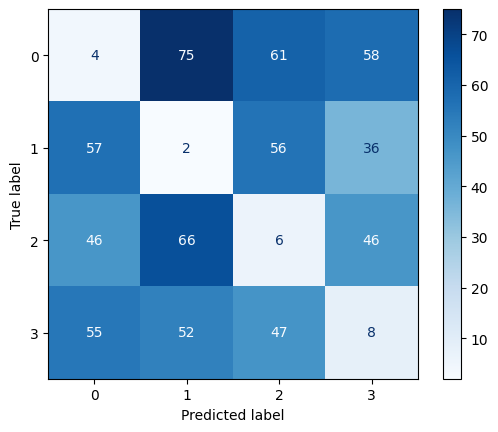

In [108]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier



# Now 'data_reshaped' can be used as input to your 1D CNN model


#Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    normalized_data, labels, test_size=0.2, random_state=42
)
import numpy as np

import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Ensure that the data is in float32 format
data_train = data_train.astype(np.float32)
data_test = data_test.astype(np.float32)

# Train the XGBoost classifier
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, 'xgboost_model21_.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
f1 = f1_score(label_test, label_pred, average='weighted')
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy}')
print(f'F1 Score: {f1}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')


# Continue with the rest of your code for fitting the XGBoost model

# Train the XGBoost classifier
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(data_train, label_train)

# Save the trained XGBoost model (optional)
joblib.dump(clf, 'xgboost_model111_New.pkl')

# Predict labels for the test data
label_pred = clf.predict(data_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.2465 - loss: 2.1373 - val_accuracy: 0.2574 - val_loss: 1.5490 - learning_rate: 0.0010
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.2391 - loss: 1.3906 - val_accuracy: 0.2574 - val_loss: 2.4779 - learning_rate: 0.0010
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.2637 - loss: 1.3865 - val_accuracy: 0.2574 - val_loss: 3.2724 - learning_rate: 0.0010
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.2623 - loss: 1.3871 - val_accuracy: 0.2574 - val_loss: 3.8145 - learning_rate: 0.0010
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.2505 - loss: 1.3865 - val_accuracy: 0.2574 - val_loss: 4.1570 - learning_rate: 0.0010
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.2634 - loss: 1.3871 - val_accuracy: 0.2574 - val_loss: 4.4437 - learning_rate: 0.0010
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.2626 - loss: 1.3861 - val_

Accuracy: 7.41%
Precision: 7.51%
Recall: 7.41%
F1 Score: 7.43%


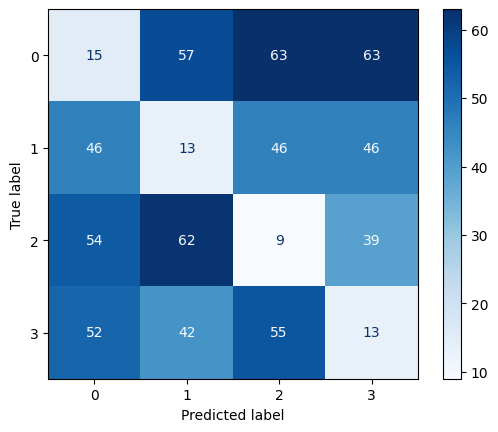

In [77]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from xgboost import XGBClassifier

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = labels  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts as separate channels
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx)

# Reshape data for CNN input (samples, height, width, channels)
n_samples, n_timesteps, n_features = data_spectrogram.shape
data_spectrogram = data_spectrogram.reshape(n_samples, n_timesteps, n_features, 1)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n_timesteps, n_features, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.4))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# Train the model
history = model.fit(data_train, label_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stopping, reduce_lr])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('cnn_feature_extractor33.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=1000, learning_rate=0.01, max_depth=10, random_state=42, subsample=0.8, colsample_bytree=0.8)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'xgboost_cnn_model33.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


Epoch 1/20


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2615 - loss: 1.8327 - val_accuracy: 0.2407 - val_loss: 1.3964
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2402 - loss: 1.3934 - val_accuracy: 0.2407 - val_loss: 1.4327
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2384 - loss: 1.3879 - val_accuracy: 0.2407 - val_loss: 1.4725
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2402 - loss: 1.3867 - val_accuracy: 0.2407 - val_loss: 1.4925
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2847 - loss: 1.3840 - val_accuracy: 0.2407 - val_loss: 1.4740
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2466 - loss: 1.3866 - val_accuracy: 0.2407 - val_loss: 1.4282
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2724 - loss: 1.3860 - val_accuracy: 0.2593 - val_loss: 1.3899
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.2417 - loss: 1.3866 - val_accuracy: 0.2704 - val_loss: 1.

Accuracy: 18.22%
Precision: 17.03%
Recall: 18.22%
F1 Score: 14.15%


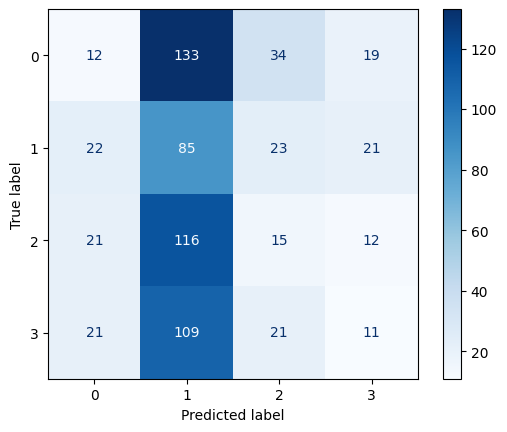

In [148]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = labels  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx)

# Reshape data for CNN input (samples, height, width, channels)
n_samples, n_timesteps, n_features = data_spectrogram.shape
data_spectrogram = data_spectrogram.reshape(n_samples, n_timesteps, n_features, 1)

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(n_timesteps, n_features, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(label)), activation='softmax'))  # Adjusted for multiclass classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=500, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the CNN model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the CNN feature extractor model
model_feature_extractor.save('cnn_feature_extractor33_New.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'xgboost_cnn_model33_New.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Epoch 1/20


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.2361 - loss: 1.8028 - val_accuracy: 0.2278 - val_loss: 1.4046
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2755 - loss: 1.4289 - val_accuracy: 0.2278 - val_loss: 1.4139
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2333 - loss: 1.4379 - val_accuracy: 0.2278 - val_loss: 1.3988
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2648 - loss: 1.4071 - val_accuracy: 0.2278 - val_loss: 1.4014
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2435 - loss: 1.4014 - val_accuracy: 0.2574 - val_loss: 1.3918
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2585 - loss: 1.4073 - val_accuracy: 0.2278 - val_loss: 1.4266
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.2460 - loss: 1.4033 - val_accuracy: 0.2407 - val_loss: 1.4147
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2624 - loss: 1.3996 - val_accuracy: 0.2278 - val_loss: 1.

Accuracy: 3.26%
Precision: 3.38%
Recall: 3.26%
F1 Score: 3.24%


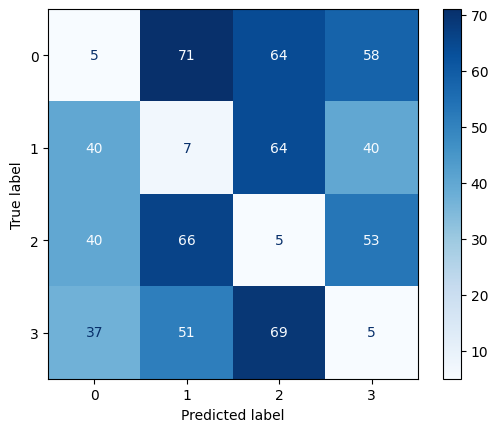

In [87]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier

# Assuming data_real is your complex-valued data and label is the corresponding labels
# Example data_real and label (replace with actual data loading mechanism)
data_real = normalized_data  # complex-valued data array
label = labels  # corresponding labels

# Split the complex-valued data into real and imaginary parts
real_part = np.real(data_real)
imaginary_part = np.imag(data_real)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Combine real and imaginary parts along the last axis
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_normalized.shape
data_normalized_2d = data_normalized.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_normalized_2d)

# Apply STFT to get the spectrogram
_, _, Zxx = stft(data_scaled, nperseg=64)
data_spectrogram = np.abs(Zxx)

# Reshape data for LSTM input (samples, timesteps, features)
n_samples, n_timesteps, n_features = data_spectrogram.shape

# Split the data into training and testing sets
data_train, data_test, label_train, label_test = train_test_split(
    data_spectrogram, label, test_size=0.2, random_state=42
)

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_timesteps, n_features)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))

model.add(Dense(10, activation='softmax'))  # Assuming binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=70, restore_best_weights=True)
history = model.fit(data_train, label_train, epochs=20, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

# Extract features from the BiLSTM model
model_feature_extractor = Sequential(model.layers[:-2])  # Remove the last two layers to get features
features_train = model_feature_extractor.predict(data_train)
features_test = model_feature_extractor.predict(data_test)

# Save the BiLSTM feature extractor model
model_feature_extractor.save('bilstm_feature_extractor33_New.h5')

### Step 3: Classification with XGBoost

# Train the XGBoost classifier on the extracted features
clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
clf.fit(features_train, label_train)

# Save the XGBoost model
joblib.dump(clf, 'xgboost2_model334_New.pkl')

# Predict and evaluate
label_pred = clf.predict(features_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Confusion matrix
conf_matrix = confusion_matrix(label_test, label_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [ ]:
# Plot the spectrogram for the first sample
sample_index = 0  # Change this index to plot a different sample
f, t, Zxx = stft(data_scaled[sample_index], nperseg=64)
plt.figure(figsize=(10, 6))
plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
plt.title(f'Spectrogram of Sample {sample_index}')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Intensity')
plt.show()

In [ ]:
ChannelIndSpectrogram

In [62]:
#number_of_legitmate = samples_from_each_device*2
# legitmate_data = data[0:number_of_legitmate]
# illegitmate_data = data[number_of_legitmate:]
#legitmate_labels = labels[0:number_of_legitmate]
#illegitmate_labels = labels[number_of_legitmate:]

# legitmate = 0
# illegitmate = 1

#binary_labels = np.where(labels <=1, 0, 1)

In [24]:
#np.unique(binary_labels[number_of_legitmate:])

array([1])

In [66]:
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, binary_labels, test_size=0.3, shuffle=True)


In [67]:
data_real_values_train[0].shape

(1, 2000)

In [68]:

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(1, crop_len*2)))
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
#cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(1, activation='sigmoid'))

#cnn_model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model_to_train = cnn_model

# loss1 = keras.losses.CategoricalFocalCrossentropy()
# loss2 = keras.losses.CategoricalCrossentropy()

#loss1 = keras.losses.BinaryFocalCrossentropy()
loss2 = keras.losses.BinaryCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.01) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.1) # https://keras.io/api/optimizers/rmsprop/
optimizer = keras.optimizers.SGD(learning_rate=0.01) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss2, metrics=['accuracy'])

train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data = (data_real_values_test, label_test),
                                   epochs=15, batch_size=64)

Epoch 1/15


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5019 - loss: 0.6932 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 2/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4941 - loss: 0.6932 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 3/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4945 - loss: 0.6932 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 4/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5110 - loss: 0.6931 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 5/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5073 - loss: 0.6932 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 6/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4987 - loss: 0.6932 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 7/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5060 - loss: 0.6932 - val_accuracy: 0.5010 - val_loss: 0.6931
Epoch 8/15
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5093 - loss: 0.6931 - val_accuracy: 0.5010 - val_loss: 0.6931
Epo

In [ ]:
import numpy as np

# Step 1: Normalize the preamble (if needed)
# Here, normalization means scaling the preamble so that it has a unit power.
preamble_power = np.mean(np.abs(preamble)**2)
normalized_preamble = preamble / np.sqrt(preamble_power)

# Step 2: Repeat or extend the preamble if needed (example shows a simple repeat)
# For this example, let's assume we need to repeat the preamble to create a longer pilot sequence
num_repeats = 1  # Change this as needed
pilot_sequence = np.tile(normalized_preamble, (num_repeats, 1))

# Print the resulting pilot sequence
#print("Normalized Preamble:\n", normalized_preamble)
print("Pilot Sequence:\n", pilot_sequence)
